# 1 - Multi-Modal LLM: PaliGemma

The PaliGemma model is a multi-modal large language model (MLLM) capable of processing various input modalities (image, audio, video) to generate text.

Notebook based on:
- https://colab.research.google.com/drive/1gOhRCFyt9yIoasJkd4VoaHcIqJPdJnlg?usp=sharing#scrollTo=zchyD7YIsmi7

In [1]:
!pip install -q -U accelerate bitsandbytes transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 40.7 MB/s eta 0:00:00


In [2]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
import torch
from transformers import AutoTokenizer, PaliGemmaForConditionalGeneration, PaliGemmaProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "google/paligemma-3b-mix-224"
model = PaliGemmaForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.bfloat16)
model.to(device)

processor = PaliGemmaProcessor.from_pretrained(model_id)  # It takes the input and prepare it for the model to use

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

## 1.1 - Model Architecture

The model architecture with its core components is summarized here:

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/6.3/multi-modal-llm.png)


- **Modality Encoder**:
processes different input data types into a unified representation. For vision, it uses the SiglipVisionModel, which includes embeddings to convert images into patch embeddings, and an encoder with multiple layers of self-attention and MLP.

- **Modality Interface**:
projects the encoded data into a format suitable for the language model using the PaliGemmaMultiModalProjector, a linear layer that converts encoded modalities to match the language model's input dimensions.

- **Large Language Model (LLM)**:
generates text based on the unified representation. The GemmaForCausalLM language model includes an embedding layer for text tokens, multiple decoder layers with self-attention and MLP, and an LM head to output the final text predictions.


Vision Transformer

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/6.3/vision-transformer.png)



In [5]:
# Three elements:
# 1. vision_tower (modality encoder)
# 2. multi_modal_projector (modality interface)
# 3. language model (multi-modal LLM)
print(model)

PaliGemmaForConditionalGeneration(
  (model): PaliGemmaModel(
    (vision_tower): SiglipVisionModel(
      (embeddings): SiglipVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(256, 1152)
      )
      (encoder): SiglipEncoder(
        (layers): ModuleList(
          (0-26): 27 x SiglipEncoderLayer(
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (self_attn): SiglipAttention(
              (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (mlp): SiglipMLP(
              (activation_

# 2 - Inference

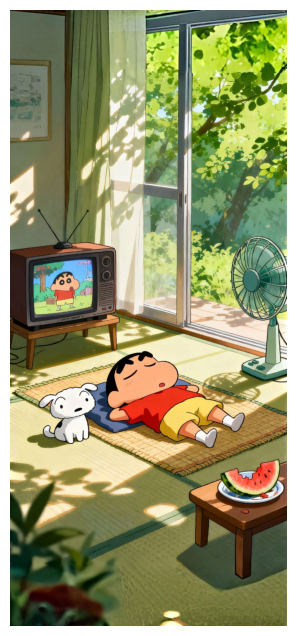

In [20]:
import torch
import numpy as np
from PIL import Image
import requests
import matplotlib.pyplot as plt

def load_image(url):
  input_image = Image.open(requests.get(url, stream=True).raw)

  plt.figure(figsize=(8, 8))
  plt.imshow(input_image)
  plt.axis('off')  # Hide axes
  plt.show()

  return input_image

def show_image(img, figsize=(8, 8)):
  plt.figure(figsize=figsize)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

url = "https://i.pinimg.com/1200x/de/ca/df/decadf4824f3a693404989e0cd40eb42.jpg"
img = load_image(url)

In [21]:
inputs = processor(text="Describe the image", images=img,
                  padding="longest", do_convert_rgb=True, return_tensors="pt").to("cuda")
# input_ids: placeholder tokens for the image before going into the LLM + tokens for the text
print(inputs)

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


{'input_ids': tensor([[257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         25715

In [22]:
def query(image, prompt):
  inputs = processor(text=prompt, images=image,
                  padding="longest", do_convert_rgb=True, return_tensors="pt").to("cuda")
  inputs = inputs.to(dtype=model.dtype)

  with torch.no_grad():
    output = model.generate(**inputs, max_length=496)

  return processor.decode(output[0], skip_special_tokens=True)

## 2.1 - Image description

Describe the image:
In this image we can see a cartoon picture. In the picture we can see a boy, dog, watermelon, table, fan, window, curtain, wall, photo frame and some objects.


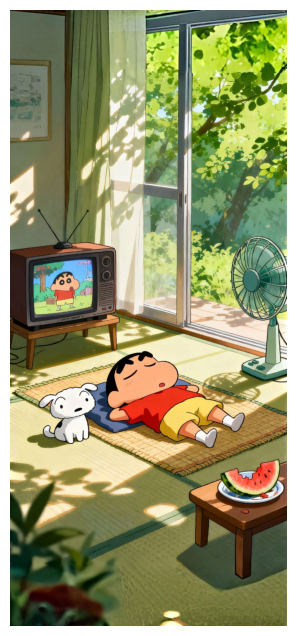

In [25]:
print(query(img, "<image>Describe the image:"))
show_image(img)

## 2.2 - Visual Q&A

In [26]:
print(query(img, "<image>What color is the dog?"))

What color is the dog?
white


In [27]:
print(query(img, "<image>Where is the watermelon?"))

Where is the watermelon?
on table


In [28]:
print(query(img, "<image>What color are the boy's shorts?"))

What color are the boy's shorts?
yellow


## 2.3 - OCR

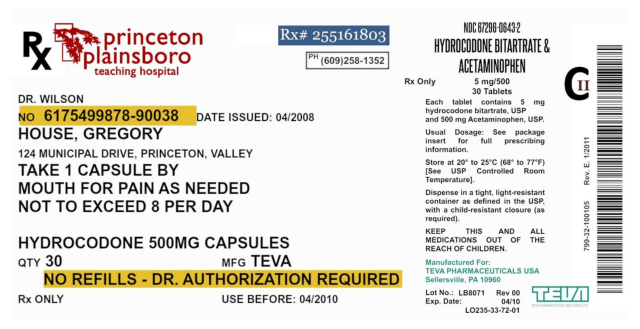

What is this?
hydrocodone 500mg capsules


In [35]:
prescription = load_image("https://i.pinimg.com/1200x/f0/02/0f/f0020f0cb4867cd6ff1d6f1ecbb8f0f8.jpg")

print(query(prescription, "<image>What is this?"))

In [36]:
print(query(prescription, "<image>What did the doctor prescibe?"))

What did the doctor prescibe?
hydrocodone 500mg capsules


In [37]:
print(query(prescription, "<image>Who prescribed the medicine?"))

Who prescribed the medicine?
DR. WILSON


In [40]:
print(query(prescription, "<image>How many capsules can the patient take for most per day?"))

How many capsules can the patient take for most per day?
1


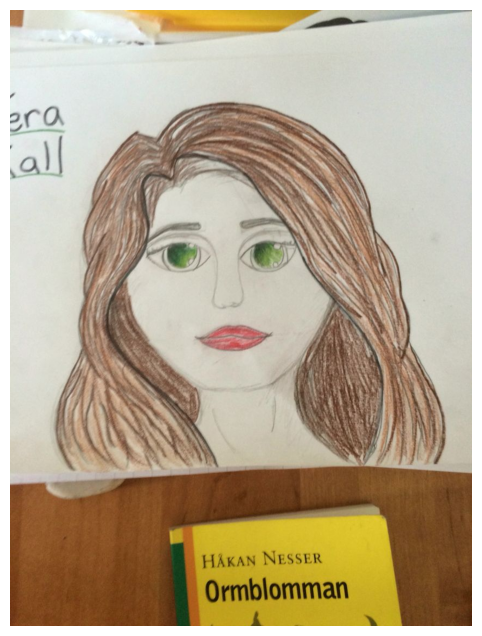

What is in the image?
drawing


In [41]:
book = load_image("https://i.pinimg.com/1200x/d9/5b/4f/d95b4fd2a69623a8d720ae2bae2e176a.jpg")

print(query(book, "<image>What is in the image?"))

In [42]:
print(query(book, "<image>Who is the author of the book?"))

Who is the author of the book?
hakan nesser


In [43]:
print(query(book, "<image>What's the title of the book?"))

What's the title of the book?
ormblomman


## 2.4 - Object detection

In [50]:
output = query(img, "<image>detect dog")
print(output)

detect dog
<loc0616><loc0100><loc0720><loc0336> dog


In [46]:
import re
from PIL import ImageDraw

def display_bounding_box(pil_image, model_output):
  # Parse the location tokens
  loc_values = re.findall(r'<loc(\d+)>', model_output)
  loc_values = [int(val) for val in loc_values]

  # Convert normalized coordinates to image coordinates
  width, height = pil_image.size
  y_min, x_min, y_max, x_max = [
      int(loc_values[i] / 1024 * (height if i % 2 == 0 else width))
      for i in range(4)
  ]

  # Create a copy of the image to draw on
  draw_image = pil_image.copy()
  draw = ImageDraw.Draw(draw_image)

  # Draw the bounding box
  draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)

  # Display the image
  plt.figure(figsize=(10, 10))
  plt.imshow(draw_image)
  plt.axis('off')
  plt.show()

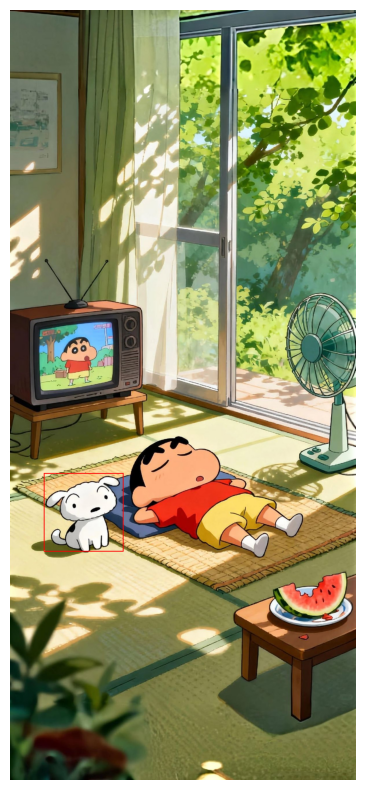

In [51]:
display_bounding_box(img, output)